In [41]:
import pandas as pd
Sales = pd.read_csv('../LTV-Capstone-Project/Data/Online_Sales.csv')
Coupon = pd.read_csv('../LTV-Capstone-Project/Data/Discount_Coupon.csv')

In [55]:
ltv_final = pd.read_csv("Customer_LTV_Summary.csv")
ltv_final.head(2)

,CustomerID,frequency,recency,T,monetary_value,predicted_purchases_6m,predicted_avg_value,predicted_LTV_6m,Gender,Location,Tenure_Months
0,12347,0.0,0.0,169.0,0.0,0.418871,1389.001199,581.812384,M,New York,20
1,12348,0.0,0.0,79.0,0.0,0.644901,1389.001199,895.767812,M,California,39


In [46]:
print(Coupon.dtypes)
print(Coupon['Month'].unique())

Month               object
Product_Category    object
Coupon_Code         object
Discount_pct         int64
dtype: object
['Jan' 'Feb' 'Mar' 'Apr' 'May' 'Jun' 'Jul' 'Aug' 'Sep' 'Oct' 'Nov' 'Dec']


In [47]:
# Cleaning date format - Map month abbreviations to month numbers
import calendar
month_map = {abbr: num for num, abbr in enumerate(calendar.month_abbr) if abbr}
Coupon['Month_Num'] = Coupon['Month'].map(month_map)

In [48]:
# Create Month_Num in the Sales DataFrame
Sales['Transaction_Date'] = pd.to_datetime(Sales['Transaction_Date'], errors='coerce')
Sales['Month_Num'] = Sales['Transaction_Date'].dt.month

In [49]:
# Normalize Product_Category in both tables
Sales['Product_Category'] = Sales['Product_Category'].str.strip().str.upper()
Coupon['Product_Category'] = Coupon['Product_Category'].str.strip().str.upper()

In [50]:
# Cleaning date format to merge Sales and Coupon data
SalesCoupon = Sales.merge(
    Coupon[['Month_Num', 'Product_Category', 'Coupon_Code', 'Discount_pct']],
    on=['Month_Num', 'Product_Category'],
    how='left',
    indicator=True
)

print(SalesCoupon['_merge'].value_counts())
print(SalesCoupon.loc[SalesCoupon['_merge']=='both',
                      ['Month_Num', 'Product_Category', 'Coupon_Code', 'Discount_pct']].head())

_merge
both          52524
left_only       400
right_only        0
Name: count, dtype: int64
   Month_Num Product_Category Coupon_Code  Discount_pct
0          1         NEST-USA      ELEC10          10.0
1          1         NEST-USA      ELEC10          10.0
2          1           OFFICE       OFF10          10.0
3          1          APPAREL      SALE10          10.0
4          1             BAGS       AIO10          10.0


In [59]:
#Calculate Marketing Spend
SalesCoupon['Marketing_Spend'] = (
    SalesCoupon['Avg_Price'] * SalesCoupon['Quantity'] * SalesCoupon['Discount_pct'] / 100
)
customer_metrics = SalesCoupon.groupby('CustomerID').agg({
    'Marketing_Spend': 'sum'
}).reset_index()


In [60]:
#Aggregate Costs and Benefits Per Customer
customer_roi = ltv_final.merge(customer_metrics, on='CustomerID', how='left')
customer_roi['Marketing_Spend'] = customer_roi['Marketing_Spend'].fillna(0)


In [62]:
#ROI calculation

def compute_roi(row):
    spend = row['Marketing_Spend']
    ltv = row['predicted_LTV_6m']
    return (ltv - spend) / spend * 100 if spend > 0 else None

customer_roi['ROI_pct'] = customer_roi.apply(compute_roi, axis=1)
customer_roi['ROI_ratio'] = customer_roi.apply(
    lambda r: r['predicted_LTV_6m'] / r['Marketing_Spend'] if r['Marketing_Spend'] > 0 else None,
    axis=1
)

In [64]:
#ROI calculation by location and gender
roi_by_location = customer_roi.groupby('Location')['ROI_ratio'].mean().reset_index()
roi_by_gender = customer_roi.groupby('Gender')['ROI_ratio'].mean().reset_index()

Interpretation & Benchmarks

ROI ratio > 1 means you earn more in LTV than spent on coupon costs.
ROI ratio = 2 means every $1 spent generates $2 in future value, or 100% ROI.
Industry benchmarks: 200–500% marketing ROI (2–5×) is considered good in e-commerce

| Metric                     | Formula                                    |
| -------------------------- | ------------------------------------------ |
| Marketing Spend (per cust) | `Avg_Price × Quantity × Discount_pct /100` |
| Predicted Return (LTV)     | `predicted_LTV_6m` from lifetimes model    |
| ROI (%)                    | `(LTV – Spend) / Spend × 100`              |
| ROI Ratio                  | `LTV / Spend`                              |


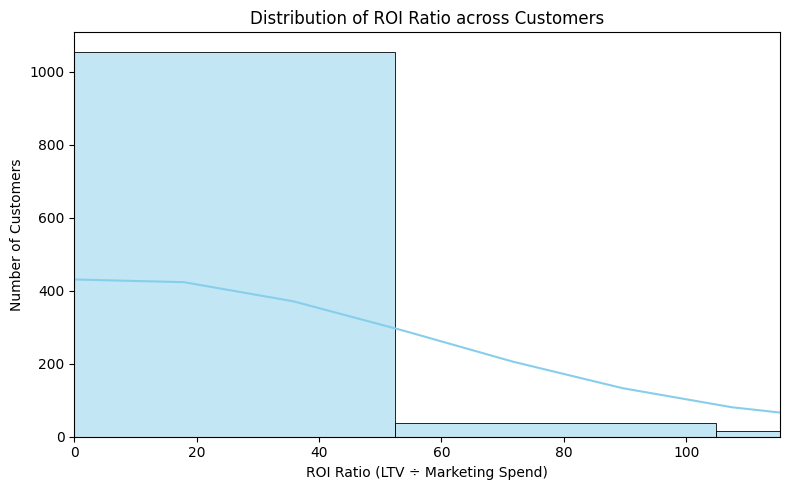

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

#ROI distribution histogram

plt.figure(figsize=(8, 5))
sns.histplot(customer_roi, x='ROI_ratio', kde=True, color='skyblue')
plt.title('Distribution of ROI Ratio across Customers')
plt.xlabel('ROI Ratio (LTV ÷ Marketing Spend)')
plt.ylabel('Number of Customers')
plt.xlim(0, customer_roi['ROI_ratio'].quantile(0.95))  # zoom into majority
plt.tight_layout()
plt.savefig('Distribution_of_ROI_by_Customers.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\dbyst\AppData\Local\Temp\ipykernel_27140\2813935574.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=roi_by_location, x='Location', y='ROI_ratio', palette='Blues_d')


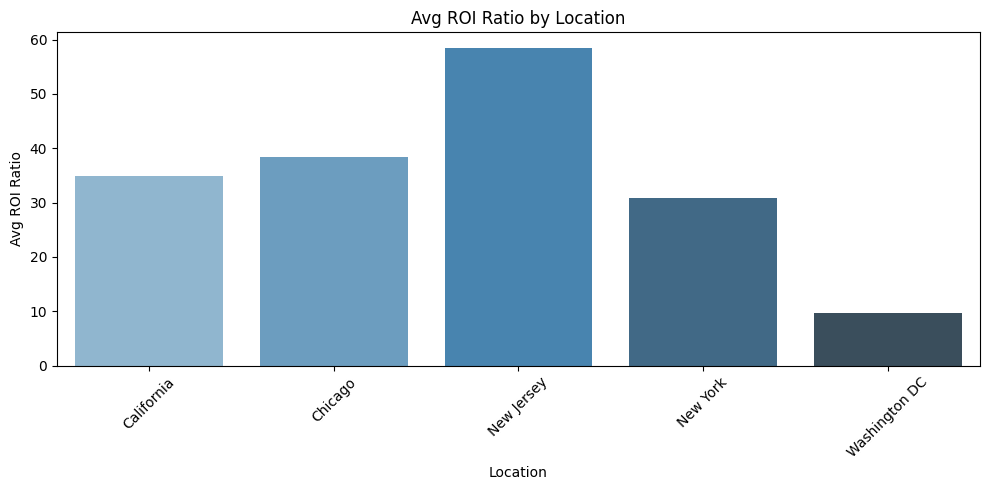

In [80]:
#Average ROI by Location

roi_by_location = customer_roi.groupby('Location')['ROI_ratio'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=roi_by_location, x='Location', y='ROI_ratio', palette='Blues_d')
plt.title('Avg ROI Ratio by Location')
plt.xlabel('Location')
plt.ylabel('Avg ROI Ratio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('avg_roi_by_location.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\dbyst\AppData\Local\Temp\ipykernel_27140\3386458058.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=roi_by_gender, x='Gender', y='ROI_ratio', palette='pastel')


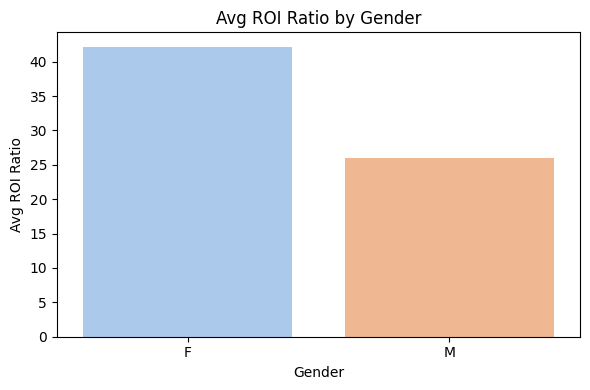

In [79]:
#Average ROI by Gender
roi_by_gender = customer_roi.groupby('Gender')['ROI_ratio'].mean().reset_index()

plt.figure(figsize=(6, 4))
sns.barplot(data=roi_by_gender, x='Gender', y='ROI_ratio', palette='pastel')
plt.title('Avg ROI Ratio by Gender')
plt.xlabel('Gender')
plt.ylabel('Avg ROI Ratio')
plt.tight_layout()
plt.savefig('avg_roi_by_gender.png', dpi=300, bbox_inches='tight')
plt.show()

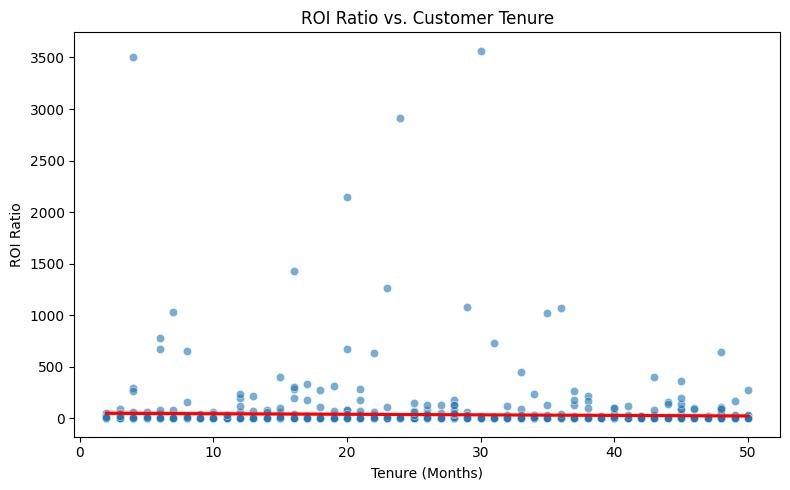

In [82]:
#Scatter Plot: ROI vs. Tenure Months
plt.figure(figsize=(8, 5))
sns.scatterplot(data=customer_roi, x='Tenure_Months', y='ROI_ratio', alpha=0.6)
sns.regplot(data=customer_roi, x='Tenure_Months', y='ROI_ratio', scatter=False, color='red')
plt.title('ROI Ratio vs. Customer Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('ROI Ratio')
plt.tight_layout()
plt.savefig('roi_vs_tenure.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# Coupon Usage
# Calculation of the total number of coupons used by each customer
coupon_usage = SalesCoupon.groupby('CustomerID')['Coupon_Code'].nunique().reset_index()
coupon_usage.columns = ['CustomerID', 'Coupon_Count']

# Merging with the original customer_roi DataFrame
customer_roi = customer_roi.merge(coupon_usage, on='CustomerID', how='left')

# Definition quartiles based on coupon usage
customer_roi['Coupon_Usage_Quartile'] = pd.qcut(customer_roi['Coupon_Count'], 4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

In [ ]:
# ROI for each customer
customer_roi['ROI_pct'] = customer_roi.apply(compute_roi, axis=1)
# Group by coupon usage quartile and calculate the average ROI
roi_by_coupon_quartile = customer_roi.groupby('Coupon_Usage_Quartile')['ROI_pct'].mean().reset_index()


C:\Users\dbyst\AppData\Local\Temp\ipykernel_27140\2150525360.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  roi_by_coupon_quartile = customer_roi.groupby('Coupon_Usage_Quartile')['ROI_pct'].mean().reset_index()


C:\Users\dbyst\AppData\Local\Temp\ipykernel_27140\3712999650.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=roi_by_coupon_quartile, x='Coupon_Usage_Quartile', y='ROI_pct', palette='viridis')


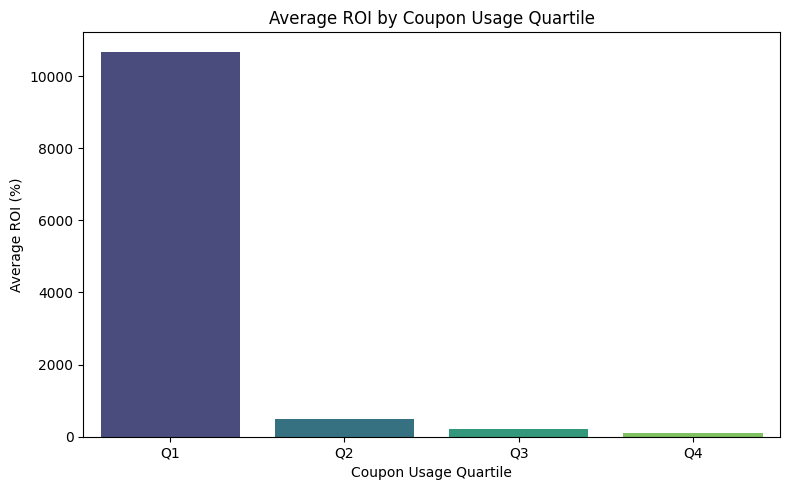

In [84]:
# Average ROI by Coupon Usage Quartile
plt.figure(figsize=(8, 5))

# Create a bar plot
sns.barplot(data=roi_by_coupon_quartile, x='Coupon_Usage_Quartile', y='ROI_pct', palette='viridis')

# Set the title and labels
plt.title('Average ROI by Coupon Usage Quartile')
plt.xlabel('Coupon Usage Quartile')
plt.ylabel('Average ROI (%)')

# Display the plot
plt.tight_layout()
plt.savefig('roi_by_coupon_quartile.png', dpi=300, bbox_inches='tight')
plt.show()

